<a href="https://colab.research.google.com/github/Hem1144/AI-ML/blob/intelligence_system/Text_encoding_and_IR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutoral 6: CN7050: Intelligent Systems
**Text represenation for AI and introducing LLMs**

In this tutorial, you will learn about:

      How text is represented in AI systems

      Word embedding models and their role in NLP

      Sentence embeddings using Transformer models

      How large language models generate text



Dr Shaheen Khatoon

Ph.D. | PMP | PMI-ACP | ITIL | PgCert TLHE

Senior Lecturer in Data Science (Computer Science and Digital Technologies) School of Architecture, Computing and Engineering

 Room: EB.1.99

(e) S.Khatoon@uel.ac.uk

(w) https://uel.ac.uk/about-uel/staff/shaheen-khatoon '''

# How to represent text for AI

## Baisc preprocessing

In [4]:
# Install dependencies if not available
!pip install -q nltk pandas

# Import libraries
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:
# -----------------------------
# Text Preprocessing Function
# -----------------------------
def preprocess_text(sentence):
    # Tokenization
    tokens = word_tokenize(sentence.lower())

    # Stopword removal
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [w for w in tokens if w.isalnum() and w not in stop_words]

    # Stemming
    ps = PorterStemmer()
    stemmed_tokens = [ps.stem(w) for w in filtered_tokens]

    return " ".join(stemmed_tokens), stemmed_tokens


In [7]:
# Example Documents
documents = [
    "Should we go to a pizzeria or do you prefer a restaurant?",
    "Natural Language Processing is a key part of artificial intelligence.",
    "Machine learning enables computers to learn from data.",
    "AI and data science are transforming healthcare analytics."
]

# Preprocess each document
processed_docs = []
print(processed_docs)
for doc in documents:
    cleaned_text, tokens = preprocess_text(doc)
    processed_docs.append({
        "Original": doc,
        "Cleaned_Text": cleaned_text,
        "Tokens": tokens
    })

# Display preprocessed results
df = pd.DataFrame(processed_docs)
print(processed_docs)
print("Preprocessed DataFrame:")
display(df)

[]
[{'Original': 'Should we go to a pizzeria or do you prefer a restaurant?', 'Cleaned_Text': 'go pizzeria prefer restaur', 'Tokens': ['go', 'pizzeria', 'prefer', 'restaur']}, {'Original': 'Natural Language Processing is a key part of artificial intelligence.', 'Cleaned_Text': 'natur languag process key part artifici intellig', 'Tokens': ['natur', 'languag', 'process', 'key', 'part', 'artifici', 'intellig']}, {'Original': 'Machine learning enables computers to learn from data.', 'Cleaned_Text': 'machin learn enabl comput learn data', 'Tokens': ['machin', 'learn', 'enabl', 'comput', 'learn', 'data']}, {'Original': 'AI and data science are transforming healthcare analytics.', 'Cleaned_Text': 'ai data scienc transform healthcar analyt', 'Tokens': ['ai', 'data', 'scienc', 'transform', 'healthcar', 'analyt']}]
Preprocessed DataFrame:


,Original,Cleaned_Text,Tokens
0,Should we go to a pizzeria or do you prefer a ...,go pizzeria prefer restaur,"[go, pizzeria, prefer, restaur]"
1,Natural Language Processing is a key part of a...,natur languag process key part artifici intellig,"[natur, languag, process, key, part, artifici,..."
2,Machine learning enables computers to learn fr...,machin learn enabl comput learn data,"[machin, learn, enabl, comput, learn, data]"
3,AI and data science are transforming healthcar...,ai data scienc transform healthcar analyt,"[ai, data, scienc, transform, healthcar, analyt]"


##One-hot encoding

In [ ]:
#one-hot encoding for a single document
import numpy as np
def one_hot_encoding(sentence):
    words = sentence.lower().split()
    vocabulary = sorted(set(words))
    word_to_index = {word: i for i, word in enumerate(vocabulary)}
    one_hot_matrix = np.zeros((len(words), len(vocabulary)), dtype=int)
    for i, word in enumerate(words):
        one_hot_matrix[i, word_to_index[word]] = 1

    return one_hot_matrix, vocabulary

# Example of usage
sentence = "Should we go to a pizzeria or do you a prefer a restaurant?"
one_hot_matrix, vocabulary = one_hot_encoding(sentence)
print("Vocabulary:", vocabulary)
print("One-Hot Encoding Matrix:\n", one_hot_matrix)

Vocabulary: ['a', 'do', 'go', 'or', 'pizzeria', 'prefer', 'restaurant?', 'should', 'to', 'we', 'you']
One-Hot Encoding Matrix:
 [[0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 1 0]
 [0 0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0]
 [1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 0 0 0 0]]


In [ ]:
# One-Hot Encoding for Entire Vocabulary

import numpy as np

# Flatten tokens from all documents to build the full vocabulary
all_tokens = [token for sublist in df["Tokens"] for token in sublist]
vocabulary = sorted(set(all_tokens))

# Create a mapping from word to index
word_to_index = {word: i for i, word in enumerate(vocabulary)}

# Initialize matrix (documents × vocabulary)
one_hot_matrix = np.zeros((len(df), len(vocabulary)), dtype=int)

# Fill one-hot matrix for each document
for i, tokens in enumerate(df["Tokens"]):
    for token in tokens:
        if token in word_to_index:
            one_hot_matrix[i, word_to_index[token]] = 1

# Create a labeled DataFrame for better readability
one_hot_df = pd.DataFrame(one_hot_matrix, columns=vocabulary)
one_hot_df.index = [f"Doc_{i+1}" for i in range(len(df))]

print(" Vocabulary:", vocabulary)
print("\n One-Hot Encoding Matrix for All Documents:")
display(one_hot_df)


 Vocabulary: ['ai', 'analyt', 'artifici', 'comput', 'data', 'enabl', 'go', 'healthcar', 'intellig', 'key', 'languag', 'learn', 'machin', 'natur', 'part', 'pizzeria', 'prefer', 'process', 'restaur', 'scienc', 'transform']

 One-Hot Encoding Matrix for All Documents:


,ai,analyt,artifici,comput,data,enabl,go,healthcar,intellig,key,...,learn,machin,natur,part,pizzeria,prefer,process,restaur,scienc,transform
Doc_1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,1,0,1,0,0
Doc_2,0,0,1,0,0,0,0,0,1,1,...,0,0,1,1,0,0,1,0,0,0
Doc_3,0,0,0,1,1,1,0,0,0,0,...,1,1,0,0,0,0,0,0,0,0
Doc_4,1,1,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1


##Bag-of-words

BoW is an algorithm for extracting features from text that preserves this frequency property. BoW is a very simple algorithm that ignores the position of words in the text and only considers this frequency property. The name “bag” comes precisely from the fact that any information concerning sentence order and structure is not preserved by the algorithm. For BoW, we only need a vocabulary and a way to be able to count words. In this case, the idea is to create document vectors: a single vector represents a document and the frequency of words contained in the vocabulary.

In [ ]:
def bag_of_words(sentences):
    """
    Creates a bag-of-words representation of a list of documents.
    """
    tokenized_sentences = [sentence.lower().split() for sentence in sentences]
    flat_words = [word for sublist in tokenized_sentences for word in sublist]
    vocabulary = sorted(set(flat_words))
    word_to_index = {word: i for i, word in enumerate(vocabulary)}

    bow_matrix = np.zeros((len(sentences), len(vocabulary)), dtype=int)
    for i, sentence in enumerate(tokenized_sentences):
        for word in sentence:
            if word in word_to_index:
                bow_matrix[i, word_to_index[word]] += 1

    return vocabulary, bow_matrix

# Example of usage
corpus = ["This movie is awesome awesome", "I do not say is good, but neither awesome",
             "Awesome? Only a fool can say that"]
vocabulary, bow_matrix = bag_of_words(corpus)
print("Vocabulary:", vocabulary)
print("Bag of Words Matrix:\n", bow_matrix)

Vocabulary: ['a', 'awesome', 'awesome?', 'but', 'can', 'do', 'fool', 'good,', 'i', 'is', 'movie', 'neither', 'not', 'only', 'say', 'that', 'this']
Bag of Words Matrix:
 [[0 2 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1]
 [0 1 0 1 0 1 0 1 1 1 0 1 1 0 1 0 0]
 [1 0 1 0 1 0 1 0 0 0 0 0 0 1 1 1 0]]


## TF-IDF

In BoW, we obtained a document-term matrix. However, the raw frequency is very skewed and does not always allow us to discriminate between two documents.

The document-term matrix was born in information retrieval to find documents, though words such as “good” or “bad” are not very discriminative since they are often used in text with a generic meaning. In contrast, words with low frequency are much more informative, so we are interested more in relative than absolute frequency:

Instead of using raw frequency, we can use the logarithm in base 10, because a word that occurs 100 times in a document is not 100 times more relevant to its meaning in the document. Of course, since vectors can be very sparse, we assign 0 if the frequency is 0.

Second, we want to pay more attention to words that are present only in some documents. These words will be more relevant to the meaning of the document, and we want to preserve this information. To do this, we normalize by IDF. IDF is defined as the ratio of the total number of documents in the corpus to how many documents a term is present in. To summarize, to obtain the TF-IDF, we multiply TF by the logarithm of IDF.

In [ ]:
def compute_tf(sentences):
    """Compute the term frequency matrix for a list of sentences."""
    vocabulary = sorted(set(word for sentence in sentences for word in sentence.lower().split()))
    word_index = {word: i for i, word in enumerate(vocabulary)}
    tf = np.zeros((len(sentences), len(vocabulary)), dtype=np.float32)
    for i, sentence in enumerate(sentences):
        words = sentence.lower().split()
        word_count = len(words)
        for word in words:
            if word in word_index:
                tf[i, word_index[word]] += 1 / word_count
    return tf, vocabulary

def compute_idf(sentences, vocabulary):
    """Compute the inverse document frequency for a list of sentences."""
    num_documents = len(sentences)
    idf = np.zeros(len(vocabulary), dtype=np.float32)
    word_index = {word: i for i, word in enumerate(vocabulary)}
    for word in vocabulary:
        df = sum(1 for sentence in sentences if word in sentence.lower().split())
        idf[word_index[word]] = np.log(num_documents / (1 + df)) + 1  # Smoothing
    return idf

def tf_idf(sentences):
    """Generate a TF-IDF matrix for a list of sentences."""
    tf, vocabulary = compute_tf(sentences)
    idf = compute_idf(sentences, vocabulary)
    tf_idf_matrix = tf * idf
    return vocabulary, tf_idf_matrix

vocabulary, tf_idf_matrix = tf_idf(corpus)
print("Vocabulary:", vocabulary)
print("TF-IDF Matrix:\n", tf_idf_matrix)

Vocabulary: ['a', 'awesome', 'awesome?', 'but', 'can', 'do', 'fool', 'good,', 'i', 'is', 'movie', 'neither', 'not', 'only', 'say', 'that', 'this']
TF-IDF Matrix:
 [[0.         0.4        0.         0.         0.         0.
  0.         0.         0.         0.2        0.28109303 0.
  0.         0.         0.         0.         0.28109303]
 [0.         0.11111111 0.         0.1561628  0.         0.1561628
  0.         0.1561628  0.1561628  0.11111111 0.         0.1561628
  0.1561628  0.         0.11111111 0.         0.        ]
 [0.20078073 0.         0.20078073 0.         0.20078073 0.
  0.20078073 0.         0.         0.         0.         0.
  0.         0.20078073 0.14285715 0.20078073 0.        ]]


# Use of TFIDF in IR systems

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
#this for unzip and read the file
try:
    df=pd.read_csv("IMDB Dataset.csv")
except:
    !wget https://github.com/SalvatoreRa/tutorial/blob/main/datasets/IMDB.zip?raw=true
    !unzip IMDB.zip?raw=true

--2025-11-03 14:55:23--  https://github.com/SalvatoreRa/tutorial/blob/main/datasets/IMDB.zip?raw=true
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/SalvatoreRa/tutorial/raw/refs/heads/main/datasets/IMDB.zip [following]
--2025-11-03 14:55:23--  https://github.com/SalvatoreRa/tutorial/raw/refs/heads/main/datasets/IMDB.zip
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/SalvatoreRa/tutorial/refs/heads/main/datasets/IMDB.zip [following]
--2025-11-03 14:55:23--  https://raw.githubusercontent.com/SalvatoreRa/tutorial/refs/heads/main/datasets/IMDB.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.1

In [ ]:
# Load the dataset
df = pd.read_csv("IMDB Dataset.csv")
df = df.iloc[:5000,:]

# Display the first few rows of the dataframe
print(df.head())

# Initialize the TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=1000)

# Fit and transform
tfidf_matrix = tfidf_vectorizer.fit_transform(df['review'])

# Convert the TF-IDF matrix to a DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [ ]:
# Define the query
query = "I want to watch a movie about zombie"

# Transform the query using the same TF-IDF vectorizer
query_tfidf = tfidf_vectorizer.transform([query])

# Calculate cosine similarity between the query and all documents
cosine_similarities = cosine_similarity(query_tfidf, tfidf_matrix).flatten()

df['cosine_similarity'] = cosine_similarities

reranked_df = df.sort_values(by='cosine_similarity',
                             ascending=False).reset_index(drop=True)

reranked_df

,review,sentiment,cosine_similarity
0,If you want to waste a small portion of your l...,negative,0.589198
1,This movie is god awful. Not one quality to th...,negative,0.483662
2,"Now, I'm a big fan of Zombie movies. I admit Z...",negative,0.463848
3,"""Revolt of the Zombies"" proves that having the...",negative,0.360548
4,I haven't had a chance to view the previous fi...,negative,0.343682
...,...,...,...
4995,i see hundreds of student films- this is tops....,positive,0.000000
4996,"Although I'm a girl, thankfully I have a sense...",positive,0.000000
4997,4 out of 10.<br /><br />This film was neither ...,negative,0.000000
4998,This is by far the best stand-up routine I hav...,positive,0.000000


In [ ]:
#give a look in detail to the first example
reranked_df.iloc[0,0]

'If you want to waste a small portion of your life sit in front of this predictable zombie film. It fails at the first post by not being scary OR funny. It is a dull grey movie that I guess went straight to video. Hammy and tongue in cheek acting leave a sour taste in the mouth. If you want to watch a poor but still watchable recent zombie film watch Diary of the Dead. Poor special effects, school level script. Zombie films work if they have a moral point or even a political point . This movie has nothing, there is no worthy point that zombification underscores. This is as thrilling and convincing as a Republican Convention, no sorry watching the Republican Convention would be a better example of a Zombie movie.'

# Word Embedding

Generate vectors that are small in size, composed of real (dense) numbers, and that preserve this contextual information.

Thus, the purpose is to have vectors of limited size that can represent the meaning of a word. The scattered vectors we obtained earlier cannot be used efficiently for mathematical operations or downstream tasks.
Also, the more words there are in the vocabulary, the larger the size of the vectors we get. Therefore, we want dense vectors (with real numbers) that are small in size and whose size does not increase as the number of words in the vocabulary increases.

these dense vectors can be used for different operations because they better represent the concept of similarity between words. These dense vectors are called word embeddings.

##Data load and preprocessing

In [ ]:
!pip install -q gensim umap-learn tqdm adjustText

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 86.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import os
import re
import time
import nltk
from gensim.models import Word2Vec
from tqdm import tqdm
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from adjustText import adjust_text
from umap import UMAP

In [ ]:
def preprocessing_reviews(reviews):

    """
    simple preprocessing: splitting on the space and remove word less than 1 chr
    """

    processed_reviews = []

    for review in tqdm(reviews):
        review = re.sub('<[^>]+>', '', review)
        processed = re.sub('[^a-zA-Z ]', '', review)
        words = processed.split()
        processed_reviews.append(' '.join([word.lower() for word in words if len(word) > 1]))
    return processed_reviews

df['reviews_processed'] = preprocessing_reviews(df['review'])
df['tokens'] = df['reviews_processed'].apply(nltk.word_tokenize)
df.head()

100%|██████████| 5000/5000 [00:01<00:00, 3207.38it/s]


,review,sentiment,cosine_similarity,reviews_processed,tokens
0,One of the other reviewers has mentioned that ...,positive,0.025828,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione..."
1,A wonderful little production. <br /><br />The...,positive,0.021989,wonderful little production the filming techni...,"[wonderful, little, production, the, filming, ..."
2,I thought this was a wonderful way to spend ti...,positive,0.019862,thought this was wonderful way to spend time o...,"[thought, this, was, wonderful, way, to, spend..."
3,Basically there's a family where a little boy ...,negative,0.267357,basically theres family where little boy jake ...,"[basically, theres, family, where, little, boy..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,0.063951,petter matteis love in the time of money is vi...,"[petter, matteis, love, in, the, time, of, mon..."


## Word2vec

In [ ]:
start_time = time.time()
# embedding
model = Word2Vec(sentences=df['tokens'].tolist(),
                 sg=1,
                 vector_size=100,
                 window=5,
                 workers=4)

print(f'Time needed : {(time.time() - start_time) / 60:.2f} mins')

Time needed : 0.33 mins


Once we have our embedding, we can visualize it. For example, if we try clustering the vectors of some words, words that have similar meanings should be closer together:



In [ ]:
all_words = list(model.wv.index_to_key)

# Convert to DataFrame for easier viewing
embedding_df = pd.DataFrame(embeddings, index=all_words)

# Display first few embeddings
print("\n=== Word Embeddings Sample ===")
display(embedding_df.head(10))

# display embedding for a specific word
word = 'love'  # <-- change to any word in your vocab
if word in model.wv:
    print(f"\nEmbedding for '{word}':\n", model.wv[word])
else:
    print(f"\nWord '{word}' not in vocabulary.")


=== Word Embeddings Sample ===


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
the,0.012338,0.313313,0.145100,0.037314,0.015930,-0.175705,0.170597,0.342776,-0.252302,-0.288078,...,0.198202,-0.116009,-0.092883,0.097966,0.346736,0.239113,0.117740,-0.058934,0.208093,0.154167
and,0.134682,0.325658,0.001203,0.135575,0.015877,-0.302835,-0.169765,0.426647,0.019684,-0.452069,...,0.155613,0.148523,-0.004190,-0.135056,0.304369,0.100860,0.027987,0.046846,-0.210940,-0.117061
of,0.052011,0.152977,-0.119471,-0.035030,-0.171498,-0.111423,-0.239469,0.383156,-0.150857,-0.125180,...,-0.041855,-0.294409,0.088506,-0.187011,0.492927,0.228585,-0.027315,0.028550,-0.119642,-0.249275
to,0.077519,0.208892,0.039928,0.028621,0.136316,-0.422598,0.240107,0.721244,0.713481,-0.175055,...,0.117684,0.254578,-0.403286,-0.192500,0.603148,0.311936,-0.024124,-0.305715,-0.113702,-0.070900
is,-0.359902,-0.046754,-0.185639,0.071479,-0.211031,-0.243895,0.023164,0.463418,0.178177,-0.230739,...,-0.063063,-0.031999,0.010204,0.273077,0.335847,0.112283,0.042624,0.106522,-0.023615,0.093824
in,-0.065287,0.276323,0.189219,-0.160902,-0.350229,-0.232909,-0.043510,0.367397,0.068185,0.193028,...,0.501933,-0.078001,-0.115428,0.004973,0.484874,0.449788,0.110379,-0.159441,0.054095,-0.299414
it,0.145376,0.353638,0.093785,-0.088343,-0.213174,-0.376860,0.319348,0.499321,-0.310564,-0.131350,...,0.264217,0.003850,0.098712,-0.140689,0.333170,0.349097,-0.223786,-0.060843,-0.016549,0.111913
this,0.256897,0.091520,0.276289,0.211247,-0.391885,-0.309951,0.140323,0.436522,-0.201284,-0.309567,...,0.557761,-0.069591,-0.209094,0.068149,0.418903,-0.031492,-0.241106,-0.064699,0.024874,0.082584
that,-0.130609,0.395545,-0.063280,-0.040831,-0.051134,-0.123723,0.114772,0.396536,0.128265,-0.247812,...,0.292862,-0.080483,0.000154,-0.107202,0.388442,0.282577,-0.110832,-0.096172,0.278400,-0.142152
was,-0.262752,0.218048,-0.325372,0.440369,-0.399793,-0.320941,-0.046805,0.501704,-0.135485,-0.054833,...,0.314935,0.090826,0.270547,0.359138,0.430790,-0.115051,-0.091694,-0.002170,0.141667,0.216749



Embedding for 'love':
 [ 0.0628069   0.4717827  -0.15149786  0.39491978 -0.0494485   0.01760162
  0.551305    0.3791465  -0.1780295  -0.2721025  -0.3487414  -0.39225456
 -0.25332513  0.26279914  0.05920301 -0.06113205 -0.38240504  0.59075826
 -0.10978506 -0.63008577 -0.14544414 -0.11722335  0.21067198 -0.26478222
 -0.03347863 -0.15971985 -0.2884307  -0.25170007 -0.07063447  0.04461943
  0.27017832 -0.05391076  0.03013221  0.01196067 -0.47779933  0.19314584
  0.05132506 -0.37791973 -0.10676209  0.11874396 -0.35057503 -0.31774685
 -0.06149433  0.15963562 -0.01191935 -0.49332827  0.2178178  -0.26135173
  0.08778144  0.4831367   0.43137723 -0.16528608  0.2321634  -0.00317804
  0.09479047 -0.09362503  0.21500687 -0.16549475 -0.0446067   0.25380078
 -0.09130144  0.13089773 -0.24086294 -0.30961266 -0.17270392  0.2563059
  0.12764916 -0.07372927 -0.105375    0.1316033  -0.22527225  0.44114193
  0.17851904  0.09044652  0.13025734  0.6231276  -0.05908431  0.03555044
 -0.27003828  0.1341773  -0.

Once we have our embedding, we can visualize it. For example, if we try clustering the vectors of some words, words that have similar meanings should be closer together:

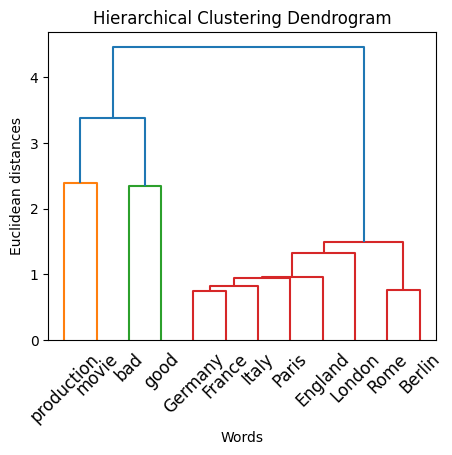

In [ ]:
# Entire set of words in the model
all_words = list(model.wv.index_to_key)
all_vectors = np.array([model.wv[word] for word in all_words])

# Highlighted words and their vectors
highlight_words = ['Berlin', 'Paris', 'London','Rome', 'Italy',
                   'France', 'Germany', 'England', 'movie', 'production', 'good', 'bad']
highs = [w.lower() for w in highlight_words]
indices = [all_words.index(word) for word in highs if word in all_words]
highlight_vectors = np.array([all_vectors[index] for index in indices])

linked = linkage(highlight_vectors, 'ward')

plt.figure(figsize=(5, 4))
dendrogram(linked,
           orientation='top',
           labels=highlight_words,
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Words')
plt.ylabel('Euclidean distances')
plt.xticks(rotation=45)
plt.savefig('word_dendrogram.jpg', format='jpeg', bbox_inches='tight')
plt.show()

Another way to visualize vectors is to use dimensionality reduction techniques.

Vectors are multidimensional (100-1,024), so it is more convenient to reduce them to two or three dimensions so that they can be visualized more easily.

Some of the most commonly used techniques are principal component analysis (PCA) and t-distributed stochastic neighbor embedding (t-SNE).

Uniform Manifold Approximation and Projection (UMAP), on the other hand, is a technique that has become the first choice for visualizing multidimensional data in recent years:

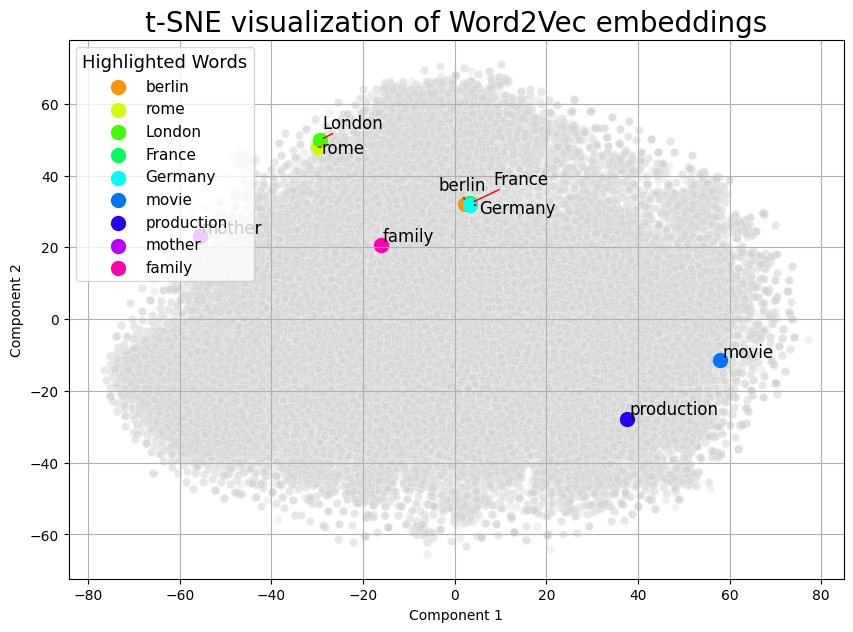

In [ ]:
# Apply t-SNE to the entire set of vectors
tsne = TSNE(n_components=2, random_state=0)
Y_tsne = tsne.fit_transform(all_vectors)

highlight_words = ['berlin', 'rome', 'London', 'France', 'Germany',
                    'movie', 'production', 'mother', 'family']

highs = [w.lower() for w in highlight_words]
indices = [all_words.index(word) for word in highs if word in all_words]
highlight_vectors = np.array([all_vectors[index] for index in indices])
Y_highlight = Y_tsne[indices]


plt.figure(figsize=(10, 7))


sns.scatterplot(x=Y_tsne[:, 0], y=Y_tsne[:, 1], color="lightgrey", alpha=0.3)

# Plot highlighted words
palette = sns.color_palette("hsv", len(highlight_words))
texts = []
for i, word in enumerate(highlight_words):
    plt.scatter(Y_highlight[i, 0], Y_highlight[i, 1], color=palette[i], s=100, label=word)
    # adjust text
    texts.append(plt.text(Y_highlight[i, 0], Y_highlight[i, 1], word, fontsize=12))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

plt.title('t-SNE visualization of Word2Vec embeddings', fontsize=20)
plt.xlabel('Component 1')
plt.ylabel('Component 2')


plt.grid(True)
plt.legend(title='Highlighted Words', title_fontsize='13', fontsize='11')
plt.savefig('word_tsne.jpg', format='jpeg')
plt.show()

## calculate similarity between words

Once we have obtained vector representations, we need a method to calculate the similarity between them.


This is crucial in many applications—for instance, to find words in an embedding space that are most similar to a given word, we compute the similarity between its vector and those of other words. Similarly, given a query sentence, we can retrieve the most relevant documents by comparing its vector with document embeddings and selecting those with the highest similarity.

Most similarity measures are based on the dot product. This is because the dot product is high when the two vectors have values in the same dimension. In contrast, vectors that have zero alternately will have a dot product of zero, thus orthogonal or dissimilar. This is why the dot product was used as a similarity measure for word co-occurrence matrices or with vectors derived from document TF matrices:

The normalized dot product is equivalent to the cosine of the angle between the two vectors, hence cosine similarity:

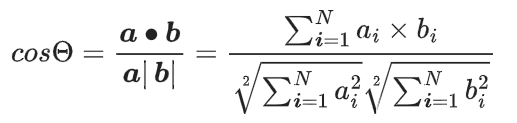

Cosine similarity has some interesting properties:

It is between -1 and 1. Opposite or totally dissimilar vectors will have a value of -1, 0 for orthogonal vectors (or totally dissimilar for scattered vectors), and 1 for perfectly similar vectors. Since it measures the angle between two vectors, the interpretation is easier and is within a specific range, so it allows one intuitively to understand the similarity or dissimilarity.

It is fast and cheap to compute.

It is less sensitive to word frequency and, thus, more robust to outliers.

It is scale-invariant, meaning that it is not influenced by the magnitude of the vectors.
Being normalized, it can also be used with high-dimensional data.


/tmp/ipython-input-1974943856.py:19: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  if np.cross(v1, v2) < 0:


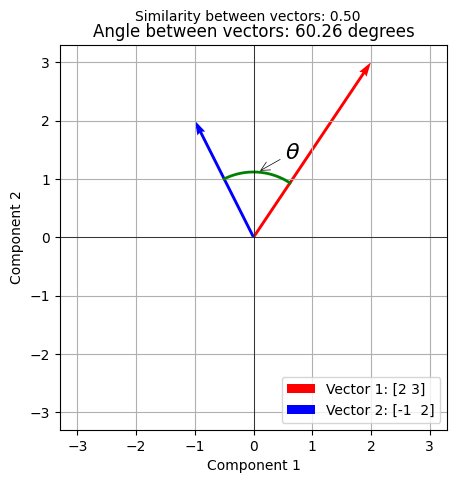

In [ ]:
def plot_vectors_and_angle(v1, v2):

    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    cosine_similarity = dot_product / (norm_v1 * norm_v2)
    angle_radians = np.arccos(cosine_similarity)
    angle_degrees = np.degrees(angle_radians)


    fig, ax = plt.subplots(figsize=(5, 5))


    ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='r', label=f"Vector 1: {v1}")
    ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='b', label=f"Vector 2: {v2}")


    start_angle = np.arctan2(v1[1], v1[0])
    if np.cross(v1, v2) < 0:
        angle_radians = -angle_radians


    theta = np.linspace(start_angle, start_angle + angle_radians, 100)
    r = 0.5 * min(np.linalg.norm(v1), np.linalg.norm(v2))
    x = r * np.cos(theta)
    y = r * np.sin(theta)


    ax.plot(x, y, linestyle='-', color='green', lw=2)


    midpoint = (start_angle + angle_radians / 2)
    ax.annotate(r'$\theta$', xy=(r * np.cos(midpoint), r * np.sin(midpoint)), xytext=(20, 10),
                textcoords='offset points', fontsize=16, arrowprops=dict(arrowstyle='->', lw=0.5))


    max_range = np.max(np.abs(np.vstack([v1, v2, [x.max(), y.max()]]))) * 1.1  # 10% padding
    ax.set_xlim([-max_range, max_range])
    ax.set_ylim([-max_range, max_range])


    plt.grid(True)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.title(f'Angle between vectors: {angle_degrees:.2f} degrees')
    plt.suptitle(f'Similarity between vectors: {cosine_similarity:.2f}', fontsize=10, y=.95)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.legend(loc='lower right')
    plt.savefig('cosine_similarity.jpg', format='jpeg', bbox_inches='tight')
    plt.show()

    return cosine_similarity, angle_degrees

# Example usage
v1 = np.array([2, 3])
v2 = np.array([-1, 2])
cos_sim, angle = plot_vectors_and_angle(v1, v2)

## Properties of embeddings

Embeddings are a surprisingly flexible method and manage to encode different syntactic and semantic properties that can both be visualized and exploited for different operations.

Once we have a notion of similarity, we can search for the words that are most similar to a word w. Note that similarity is defined as appearing in the same context window; the model cannot differentiate synonyms and antonyms.

In addition, the model is also capable of representing grammatical relations such as superlatives or verb forms.

Another interesting relationship we can study is analogies. The parallelogram model is a system for representing analogies in a cognitive space. The classic example is king:queen::man:? (which in a formula would be a:b::a*:?). Given that we have vectors, we can turn this into an a-a*+b operation.

We can test this in Python using the embedding model we have trained:

We can check the most similar words
We can test the analogy
We can then test the capacity to identify synonyms and antonyms
The code for this process is as follows:

In [ ]:
word_1 = "good"
syn = "great"
ant = "bad"
most_sim =model.wv.most_similar("good")
print("Top 3 most simalr words to {} are :{}".format(word_1, most_sim[:3]))

synonyms_dist = model.wv.distance(word_1, syn)
antonyms_dist = model.wv.distance(word_1, ant)
print("Synonyms {}, {} have cosine distance: {}".format(word_1, syn, synonyms_dist))
print("Antonyms {}, {} have cosine distance: {}".format(word_1, ant, antonyms_dist))
a = 'king'
a_star = 'man'
b = 'woman'
b_star= model.wv.most_similar(positive=[a, b], negative=[a_star])
print("{} is to {} as {} is to: {} ".format(a, a_star, b, b_star[0][0]))

Top 3 most simalr words to good are :[('decent', 0.7567450404167175), ('great', 0.713740885257721), ('cool', 0.7040130496025085)]
Synonyms good, great have cosine distance: 0.28625917434692383
Antonyms good, bad have cosine distance: 0.316448450088501
king is to man as woman is to: dunne 


# Using Sentence Transformer to understand Embeddings
The model "all-MiniLM-L6-v2" is a sentence embedding model,you can use other embedding models from HuggingFace

https://huggingface.co/sentence-transformers

In [ ]:
!pip install -q sentence-transformers scikit-learn matplotlib

In [ ]:
# --- Step 2: Import Libraries ---
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
#Load Pretrained Embedding Model ---
# You can replace this model with others like "all-MiniLM-L6-v2" or "paraphrase-MiniLM-L3-v2"
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
#Example Sentences ---
sentences = [
    "Cats are wonderful pets.",
    "Dogs are loyal and friendly.",
    "The sky is blue and clear today.",
    "I love to play with my dog.",
    "Artificial intelligence is transforming healthcare."
]


In [ ]:
#display embedding of a single word
word = "pets"
# Generate embedding
embedding = model.encode(word)

print(f"Shape of embedding vector: {embedding.shape}")
print("Embedding values (first 10 dimensions):", embedding[:10])

Shape of embedding vector: (384,)
Embedding values (first 10 dimensions): [ 7.98705500e-03  1.01199448e-02  3.97333875e-02  5.19030839e-02
 -1.06959045e-01  9.81669800e-05  7.06559941e-02 -5.11679165e-02
  5.48836812e-02  2.15079561e-02]


In [ ]:
sentence_embeddings = model.encode(sentences)
for i, sentence in enumerate(sentences):
    print(f"Sentence: {sentence}")
    print(f"Sentence embedding shape: {sentence_embeddings[i].shape}")
    print(f"First 10 dimensions: {sentence_embeddings[i][:10]}\n")

    # Generate embeddings for each word (approximation using the same model)
    words = sentence.split()
    for word in words:
        word_embedding = model.encode(word)
        print(f"  Word: {word}")
        print(f"  Embedding shape: {word_embedding.shape}")
        print(f"  First 10 dimensions: {word_embedding[:10]}\n")

    print("-" * 80)

Sentence: Cats are wonderful pets.
Sentence embedding shape: (384,)
First 10 dimensions: [ 0.07260349  0.01278543  0.09712933  0.01684647 -0.14331381  0.00660506
  0.01337398 -0.02314315 -0.01346144  0.02695634]

  Word: Cats
  Embedding shape: (384,)
  First 10 dimensions: [ 0.03606855  0.02692951  0.00767722  0.06736799 -0.08742584 -0.01713087
  0.10187884 -0.0270019   0.04178686  0.01190577]

  Word: are
  Embedding shape: (384,)
  First 10 dimensions: [-0.00790855  0.04488921  0.00858014  0.03389965 -0.05833881  0.01632332
  0.06284718 -0.03925534  0.05013677  0.04733049]

  Word: wonderful
  Embedding shape: (384,)
  First 10 dimensions: [-0.08132239 -0.01762177 -0.02899456 -0.02423163  0.0195946  -0.06225192
  0.00806099  0.02458162 -0.01809034 -0.00761433]

  Word: pets.
  Embedding shape: (384,)
  First 10 dimensions: [ 0.00933747  0.01224197  0.03138566  0.06878856 -0.10450595  0.00452367
  0.07923174 -0.06149321  0.04155993  0.00968966]

--------------------------------------

In [ ]:
# Generate Sentence Embeddings ---
#embeddings = model.encode(sentences)

print("Embeddings Generated!")
print(f"Shape of embedding matrix: {sentence_embeddings.shape}")

Embeddings Generated!
Shape of embedding matrix: (5, 384)


In [ ]:
#Calculate similarities in sentenses
similarity_matrix = model.similarity(sentence_embeddings, sentence_embeddings)
print("\nCosine Similarity Between Sentences:\n")
print(similarity_matrix)


Cosine Similarity Between Sentences:

tensor([[ 1.0000,  0.5055,  0.0583,  0.4395,  0.1039],
        [ 0.5055,  1.0000,  0.0176,  0.5127, -0.0222],
        [ 0.0583,  0.0176,  1.0000, -0.0037,  0.0909],
        [ 0.4395,  0.5127, -0.0037,  1.0000,  0.1084],
        [ 0.1039, -0.0222,  0.0909,  0.1084,  1.0000]])


Observe sentence similraity for example in first row showing similarity of sentence 1 to other four sentences. for example

 Similarity	Interpretation
S1–S2	0.5055	Moderately related — e.g., “Cats are wonderful pets” vs. “Dogs are loyal and friendly.” (both about pets/animals)

S1–S3	0.0583	Unrelated — “Cats are wonderful pets” vs. “The sky is blue”

S1–S4	0.4395	Somewhat related — “Cats are wonderful pets” vs. “I love to play with my dog.” (both about domestic animals)

S1–S5	0.1039	Very weakly related — “Cats…” vs. “AI in healthcare.” (completely different domains)

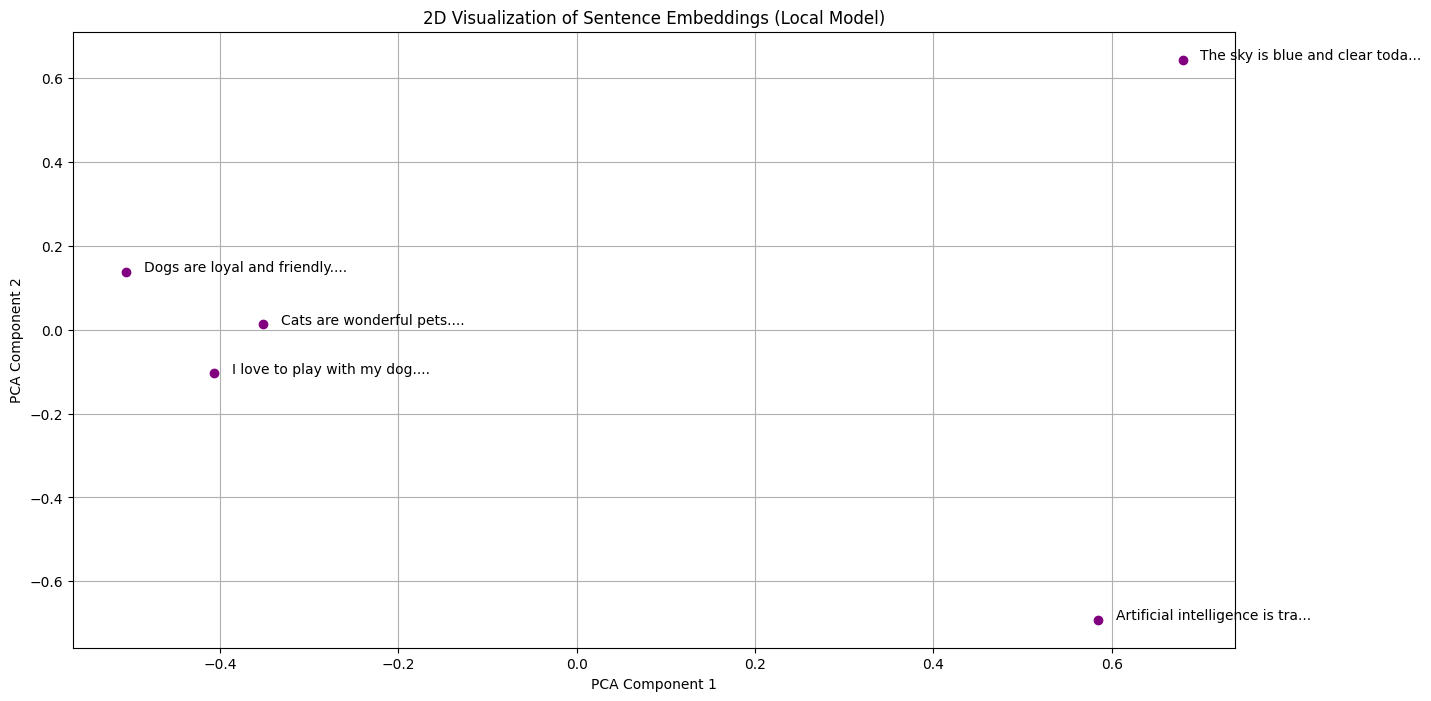

In [ ]:
# Visualize in 2D Using PCA ---
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(sentence_embeddings)

plt.figure(figsize=(15,8))
plt.scatter(reduced_embeddings[:,0], reduced_embeddings[:,1], color='purple')

for i, sentence in enumerate(sentences):
    plt.annotate(sentence[:30] + "...", (reduced_embeddings[i,0]+0.02, reduced_embeddings[i,1]))

plt.title("2D Visualization of Sentence Embeddings (Local Model)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.show()

# Understanding Text Generation Models

When you use an LLM, two models are loaded:

The generative model itself

Its underlying tokenizer

The tokenizer is in charge of splitting the input text into tokens before feeding it to the generative model.

You can find the tokenizer and model on the Hugging Face site and only need the corresponding IDs to be passed.

In this case, we use “microsoft/Phi-3-mini-4k-instruct” as the main path to the model.

Running the code will start downloading the model and depending on your internet connection can take a couple of minutes.

In [ ]:
 %%capture
!pip install -q transformers>=4.40.1 accelerate>=0.27.2

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    torch_dtype="auto",
    trust_remote_code=False,
)
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

In [ ]:
print(model)
# Explore models architecture

Phi3ForCausalLM(
  (model): Phi3Model(
    (embed_tokens): Embedding(32064, 3072, padding_idx=32000)
    (layers): ModuleList(
      (0-31): 32 x Phi3DecoderLayer(
        (self_attn): Phi3Attention(
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (qkv_proj): Linear(in_features=3072, out_features=9216, bias=False)
        )
        (mlp): Phi3MLP(
          (gate_up_proj): Linear(in_features=3072, out_features=16384, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (activation_fn): SiLUActivation()
        )
        (input_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
        (resid_attn_dropout): Dropout(p=0.0, inplace=False)
        (resid_mlp_dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (norm): Phi3RMSNorm((3072,), eps=1e-05)
    (rotary_emb): Phi3RotaryEmbedding()
  )
  (lm_head): Linear(in_features=3072, out_featur


## How Tokenizers Prepare the Inputs to the Language Model

You can find an example showing the tokenizer of GPT-4 on the

https://platform.openai.com/tokenizer


We can then proceed to the actual generation. We first declare our prompt, then tokenize it, then pass those tokens to the model, which generates its output. In this case, we’re asking the model to only generate 20 new tokens:

In [ ]:
# Define prompt
prompt = "Write an email apologizing to Sarah for the tragic gardening mishap. Explain how it happened.<|assistant|>"

# Tokenize input properly
inputs = tokenizer(prompt, return_tensors="pt")

# Generate text
generation_output = model.generate(
    input_ids=inputs["input_ids"],
    max_new_tokens=20,
    do_sample=True,
    temperature=0.7
)

# Decode and print result
output_text = tokenizer.decode(generation_output[0], skip_special_tokens=True)
print(output_text)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Write an email apologizing to Sarah for the tragic gardening mishap. Explain how it happened. Subject: Our Sincere Apologies for the Gardening Misfortune


D


In [ ]:
print(inputs["input_ids"])

tensor([[14350,   385,  4876, 27746,  5281,   304, 19235,   363,   278, 25305,
           293, 16423,   292,   286,   728,   481, 29889, 12027,  7420,   920,
           372,  9559, 29889, 32001]])


In [ ]:
# Print token IDs and decoded tokens for the input
print("\nToken IDs:", inputs["input_ids"][0].tolist())
print("\nDecoded tokens:")
for token_id in inputs["input_ids"][0]:
    print(f"{token_id.item()} -> {tokenizer.decode(token_id)}")


Token IDs: [14350, 385, 4876, 27746, 5281, 304, 19235, 363, 278, 25305, 293, 16423, 292, 286, 728, 481, 29889, 12027, 7420, 920, 372, 9559, 29889, 32001]

Decoded tokens:
14350 -> Write
385 -> an
4876 -> email
27746 -> apolog
5281 -> izing
304 -> to
19235 -> Sarah
363 -> for
278 -> the
25305 -> trag
293 -> ic
16423 -> garden
292 -> ing
286 -> m
728 -> ish
481 -> ap
29889 -> .
12027 -> Exp
7420 -> lain
920 -> how
372 -> it
9559 -> happened
29889 -> .
32001 -> <|assistant|>


In [ ]:
# Print token IDs and decoded tokens for the generated output
print("\n=== Generated Tokens ===")
gen_token_ids = generation_output[0]
print("Token IDs:", gen_token_ids.tolist())
print("Tokens:")
for token_id in gen_token_ids:
    print(f"{token_id.item()} -> '{tokenizer.decode(token_id)}'")


=== Generated Tokens ===
Token IDs: [14350, 385, 4876, 27746, 5281, 304, 19235, 363, 278, 25305, 293, 16423, 292, 286, 728, 481, 29889, 12027, 7420, 920, 372, 9559, 29889, 32001, 3323, 622, 29901, 8680, 317, 3742, 406, 6225, 11763, 363, 278, 19906, 292, 20929, 3921, 1540, 13, 13, 13, 29928]
Tokens:
14350 -> 'Write'
385 -> 'an'
4876 -> 'email'
27746 -> 'apolog'
5281 -> 'izing'
304 -> 'to'
19235 -> 'Sarah'
363 -> 'for'
278 -> 'the'
25305 -> 'trag'
293 -> 'ic'
16423 -> 'garden'
292 -> 'ing'
286 -> 'm'
728 -> 'ish'
481 -> 'ap'
29889 -> '.'
12027 -> 'Exp'
7420 -> 'lain'
920 -> 'how'
372 -> 'it'
9559 -> 'happened'
29889 -> '.'
32001 -> '<|assistant|>'
3323 -> 'Sub'
622 -> 'ject'
29901 -> ':'
8680 -> 'Our'
317 -> 'S'
3742 -> 'inc'
406 -> 'ere'
6225 -> 'Ap'
11763 -> 'ologies'
363 -> 'for'
278 -> 'the'
19906 -> 'Garden'
292 -> 'ing'
20929 -> 'Mis'
3921 -> 'fort'
1540 -> 'une'
13 -> '
'
13 -> '
'
13 -> '
'
29928 -> 'D'


# What is next

Explore the following resources to understand more on using different encoder-decoder based models:

Use a different sntence encoder from below

https://huggingface.co/models?pipeline_tag=sentence-similarity&sort=trending&search=all-MiniLM-L6-v2


See othe text generation models on Huggingface:
https://huggingface.co/models?pipeline_tag=text-generation&sort=trending

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
